# How well Data Analysts are paid based on the job roles, and skills?

### Methodology
1. Evaluate salary distribution for top 6 data jobs.
2. Find the median salary for Data Scientist.
3. Visualize median salary for highest paid skills and high demanded skills. 


## Import Libraries and Data

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 1. Evaluate salary distribution for top 6 data jobs.


In [3]:
df_US=df[df['job_country']=='United States'].dropna(subset=['salary_year_avg'])

In [4]:
job_titles=df_US['job_title_short'].value_counts().index[:6].to_list()


In [5]:
# dataframe with high demanded job roles
df_US_top6j=df_US[df_US['job_title_short'].isin(job_titles)].copy()
df_US_top6j.sample(3)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
131653,Data Analyst,Data Analyst-Assurance-Analytics Delivery-Manager,"Atlanta, GA",via Ladders,Full-time,False,Georgia,2023-08-14 08:48:57,False,True,United States,year,125000.0,NaN,Ernst & Young,"[python, javascript, azure, databricks, oracle...","{'analyst_tools': ['alteryx', 'power bi', 'dax..."
245058,Data Analyst,Real Estate Transaction Data Analyst,"Austin, TX",via Ai-Jobs.net,Full-time,False,"Texas, United States",2023-07-13 07:00:59,False,False,United States,year,100500.0,NaN,AECOM,"[excel, word, powerpoint]","{'analyst_tools': ['excel', 'word', 'powerpoin..."
34607,Data Analyst,Data Analyst (ID#10252),"Oakland, CA",via Indeed,Full-time,False,"California, United States",2023-05-15 13:00:46,True,True,United States,year,110000.0,NaN,Worldgate LLC,"[sql, python, c#, powershell, sql server, word...","{'analyst_tools': ['word', 'excel', 'outlook']..."


In [6]:
# for visualization needed to be in an order
job_order=df_US_top6j.groupby('job_title_short')['salary_year_avg'].apply('median').sort_values(ascending=False).index.to_list()

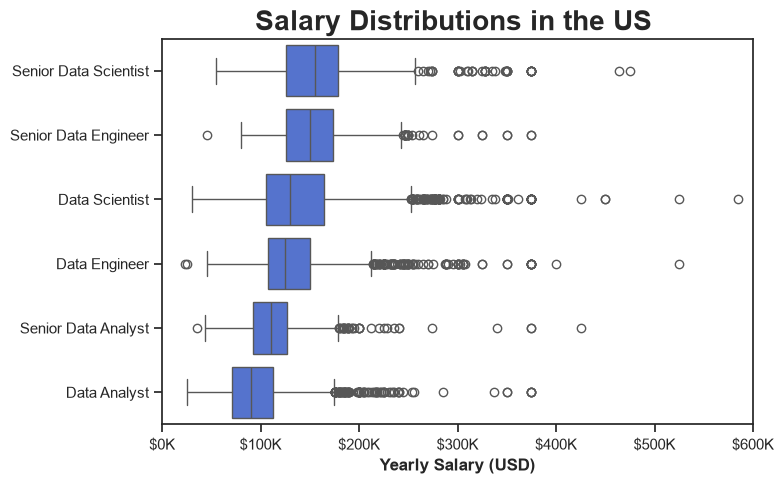

In [7]:
plt.figure(figsize=(8,5))
sns.set_theme(style='ticks')
sns.boxplot(data=df_US_top6j, x='salary_year_avg', y='job_title_short', order=job_order, color='royalblue' )

plt.title("Salary Distributions in the US ", weight='bold', fontsize=20)
plt.xlabel('Yearly Salary (USD)',weight='bold' )
plt.ylabel("")
plt.xlim(0, 600000)
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))
plt.tight_layout()
plt.show()

## 2. Find the Median Salary vs Skills for Data Analysts.


In [8]:
# the dataframe for united states is made before 
df_DA_US=df_US[df_US['job_title_short']== 'Data Analyst'].copy()


In [9]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US[['job_skills', 'salary_year_avg']].head()

,job_skills,salary_year_avg
109,python,89000.0
109,r,89000.0
109,alteryx,89000.0
109,tableau,89000.0
180,excel,90250.0


In [10]:
df_skill_count_med=df_DA_US.groupby('job_skills').agg(
    skill_count=('salary_year_avg', 'count'),
    median_sal=('salary_year_avg', 'median')
)
df_skill_count_med.head()


,skill_count,median_sal
job_skills,,
airflow,44,116250.00
airtable,5,90000.00
alteryx,106,106281.25
angular,8,107500.00
ansible,1,159640.00


In [11]:
df_DA_top_pay= df_skill_count_med.sort_values(by='median_sal', ascending=False)
df_DA_top_pay.head()

,skill_count,median_sal
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0


In [12]:
df_DA_top_demand= df_skill_count_med.sort_values(by='skill_count', ascending=False)
df_DA_top_demand.head()

,skill_count,median_sal
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0


In [13]:
# now both data framse are ready to plot one is all skill names but ordered based on the pay and other based on demand 
df_DA_top_pay=df_DA_top_pay.head(10)
df_DA_top_demand=df_DA_top_demand.head(10).sort_values(by='median_sal', ascending=False)

## 3. Visualize Median salary for highest paid skills and high demanded skills of Data Analysts Job


C:\Users\HP\AppData\Local\Temp\ipykernel_6416\1981617030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_top_demand, y=df_DA_top_demand.index,x='median_sal', ax=ax[0], palette ='light:b_r' )
C:\Users\HP\AppData\Local\Temp\ipykernel_6416\1981617030.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_top_pay, y=df_DA_top_pay.index,x='median_sal', ax=ax[1], palette = 'light:b_r')


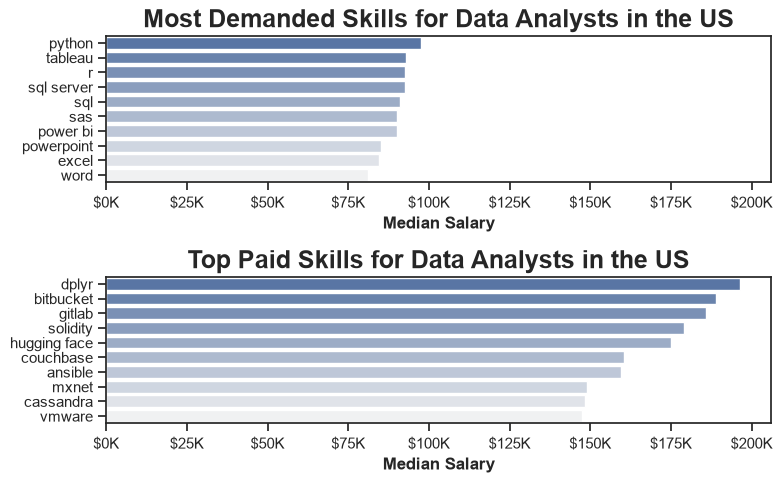

In [14]:
fig, ax= plt.subplots(2,1, figsize=(8,5))
sns.set_theme(style='ticks')

#top demands
sns.barplot(data=df_DA_top_demand, y=df_DA_top_demand.index,x='median_sal', ax=ax[0], palette ='light:b_r' )

ax[0].set_title("Most Demanded Skills for Data Analysts in the US", fontsize=18, weight='bold')
ax[0].set_ylabel("")
ax[0].set_xlabel("Median Salary", weight='bold')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,po: f"${int(x/1000)}K"))

#top paid 
sns.barplot(data=df_DA_top_pay, y=df_DA_top_pay.index,x='median_sal', ax=ax[1], palette = 'light:b_r')


ax[1].set_title("Top Paid Skills for Data Analysts in the US", fontsize=18 , weight='bold')
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary",weight='bold' )
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,po: f"${int(x/1000)}K"))


ax[0].set_xlim(ax[1].get_xlim())
plt.tight_layout()
plt.show()
